<a href="https://colab.research.google.com/github/JAPreP/TelecomX-Parte2/blob/main/TelecomX_Parte2_JulianPreciado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Desafio TELECOM X parte 2**

In [22]:

import pandas as pd

# 1. Definimos la URL directa al archivo CSV en tu GitHub
# Nota: Debes ir a tu archivo en GitHub, darle clic al botón "Raw" y copiar esa URL
url_github = "https://raw.githubusercontent.com/JAPreP/TelecomX-Parte2/refs/heads/main/TelecomX_Data_Limpia.csv"

# 2. Cargamos el dataset directamente desde la web
df_modelo = pd.read_csv(url_github)

print(f"Dataset cargado exitosamente desde GitHub. Total de registros: {len(df_modelo)}")
df_modelo.head()





Dataset cargado exitosamente desde GitHub. Total de registros: 7267


,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


# 1. Eliminación de Columnas Irrelevantes

In [7]:
# Paso 1: Eliminación de columnas no predictivas
# El ID del cliente es un identificador único que no aporta patrones al modelo
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)
    print("Columna 'customerID' eliminada exitosamente.")
else:
    print("La columna 'customerID' no se encontró o ya fue eliminada.")

# Verificación de la estructura actual
print(f"Estructura actual del dataset: {df.shape[0]} filas y {df.shape[1]} columnas.")
print("-" * 30)
print("Columnas restantes en el análisis:")
print(df.columns.tolist())

Columna 'customerID' eliminada exitosamente.
Estructura actual del dataset: 7267 filas y 20 columnas.
------------------------------
Columnas restantes en el análisis:
['Churn', 'customer_gender', 'customer_SeniorCitizen', 'customer_Partner', 'customer_Dependents', 'customer_tenure', 'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService', 'internet_OnlineSecurity', 'internet_OnlineBackup', 'internet_DeviceProtection', 'internet_TechSupport', 'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract', 'account_PaperlessBilling', 'account_PaymentMethod', 'account_Charges_Monthly', 'account_Charges_Total']


# 2. Codificación para Machine Learning

In [8]:
# Paso 2: Codificación de variables (Encoding)
# Primero, identifico las variables binarias (Sí/No) y las paso a 0 y 1
# Nota: Uso 'customer_gender' asumiendo que 1 es Masculino y 0 Femenino
mapeo_binario = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0, 'No phone service': 0, 'No internet service': 0}

columnas_binarias = ['Churn', 'customer_gender', 'customer_Partner', 'customer_Dependents',
                     'phone_PhoneService', 'account_PaperlessBilling']

for col in columnas_binarias:
    df[col] = df[col].map(mapeo_binario)

# Para las variables con más de 2 categorías, usamos One-Hot Encoding
# Esto creará columnas separadas para cada opción (Ej: Contract_Month-to-month)
df_modelo = pd.get_dummies(df, columns=[
    'phone_MultipleLines', 'internet_InternetService', 'internet_OnlineSecurity',
    'internet_OnlineBackup', 'internet_DeviceProtection', 'internet_TechSupport',
    'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract',
    'account_PaymentMethod'
], drop_first=True)

# Verifico que ahora todo sea numérico
print("Estructura después del encoding:", df_modelo.shape)
df_modelo.info()

Estructura después del encoding: (7267, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 31 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Churn                                          7043 non-null   float64
 1   customer_gender                                7267 non-null   int64  
 2   customer_SeniorCitizen                         7267 non-null   int64  
 3   customer_Partner                               7267 non-null   int64  
 4   customer_Dependents                            7267 non-null   int64  
 5   customer_tenure                                7267 non-null   int64  
 6   phone_PhoneService                             7267 non-null   int64  
 7   account_PaperlessBilling                       7267 non-null   int64  
 8   account_Charges_Monthly                        7267 non-null   float64
 9   account_

#3. Verificación de la Proporción de Cancelación (Churn)

--- Resumen de la Variable Objetivo (Churn) ---
Churn
0.0    5174
1.0    1869
Name: count, dtype: int64

Proporción en porcentaje:
Churn
0.0    73.463013
1.0    26.536987
Name: proportion, dtype: float64


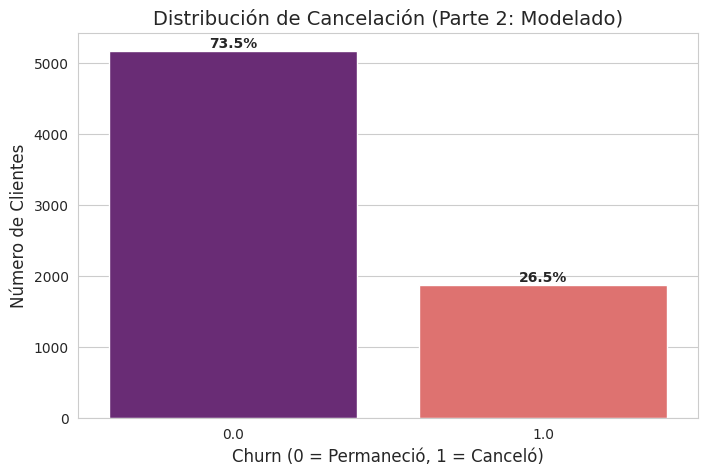

In [10]:
# Paso 3: Análisis del Desbalance de Clases (Paleta Nueva)
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculo la cantidad y proporción
conteo_churn = df_modelo['Churn'].value_counts()
proporcion_churn = df_modelo['Churn'].value_counts(normalize=True) * 100

print("--- Resumen de la Variable Objetivo (Churn) ---")
print(conteo_churn)
print("\nProporción en porcentaje:")
print(proporcion_churn)

# 2. Visualización con nueva identidad visual (Paleta 'magma')
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid") # Fondo limpio para resaltar colores

grafico = sns.barplot(x=conteo_churn.index,
                      y=conteo_churn.values,
                      palette='magma',
                      hue=conteo_churn.index,
                      legend=False)

plt.title('Distribución de Cancelación (Parte 2: Modelado)', fontsize=14)
plt.xlabel('Churn (0 = Permaneció, 1 = Canceló)', fontsize=12)
plt.ylabel('Número de Clientes', fontsize=12)

# Añadir etiquetas de porcentaje sobre las barras
for i, v in enumerate(conteo_churn.values):
    plt.text(i, v + 50, f'{proporcion_churn.values[i]:.1f}%', ha='center', fontweight='bold')

plt.show()

### Intepretacion de la Gráfica

Desbalance Moderado: No es un desbalance crítico. En la industria de telecomunicaciones, una tasa de abandono del ~26% es lo suficientemente representativa para que los modelos de Machine Learning aprendan los patrones de los clientes que se van sin necesidad de aplicar técnicas agresivas de balanceo.

Calidad de la Muestra: Tenemos casi 1,900 ejemplos de "Churn", lo cual es una base sólida para que algoritmos como Random Forest o Regresión Logística encuentren reglas de decisión confiables.

In [11]:
# Eliminamos las filas donde Churn es nulo para tener un entrenamiento limpio
df_modelo = df_modelo.dropna(subset=['Churn'])

# Verificamos que ahora todas las columnas tengan la misma cantidad de datos (7043)
print(f"Dataset final listo: {df_modelo.shape[0]} filas.")

Dataset final listo: 7043 filas.


# 4. Normalización o Estandarización

In [12]:

# Vamos a aplicar StandardScaler.
#Esto transformará nuestras variables continuas para que tengan una
# media de 0 y una desviación estándar de 1.


from sklearn.preprocessing import StandardScaler

# 1. Identificamos las columnas numéricas que no son 0 y 1
# 'customer_tenure', 'account_Charges_Monthly', 'account_Charges_Total'
columnas_numericas = ['customer_tenure', 'account_Charges_Monthly', 'account_Charges_Total']

# 2. Creamos el escalador
scaler = StandardScaler()

# 3. Aplicamos la transformación solo a esas columnas
df_modelo[columnas_numericas] = scaler.fit_transform(df_modelo[columnas_numericas])

# 4. Verificamos el resultado (la media debe ser casi 0 y desv. estándar 1)
print("Resumen de variables escaladas:")
print(df_modelo[columnas_numericas].describe().round(2))

Resumen de variables escaladas:
       customer_tenure  account_Charges_Monthly  account_Charges_Total
count          7043.00                  7043.00                7043.00
mean             -0.00                    -0.00                  -0.00
std               1.00                     1.00                   1.00
min              -1.32                    -1.55                  -1.01
25%              -0.95                    -0.97                  -0.83
50%              -0.14                     0.19                  -0.39
75%               0.92                     0.83                   0.66
max               1.61                     1.79                   2.83


### Logros de la estandarizacion

- Neutralidad: Hemos eliminado el sesgo de magnitud.
- Preparación Multi-Modelo: Ahora podemos correr tanto una Regresión Logística  como un Random Forest
- Interpretación: Un valor de $1.61$ en tenure ahora significa que ese cliente está a $1.61$ desviaciones estándar por encima del promedio de antigüedad.

# 5. Correlación y Seleccion de Variables

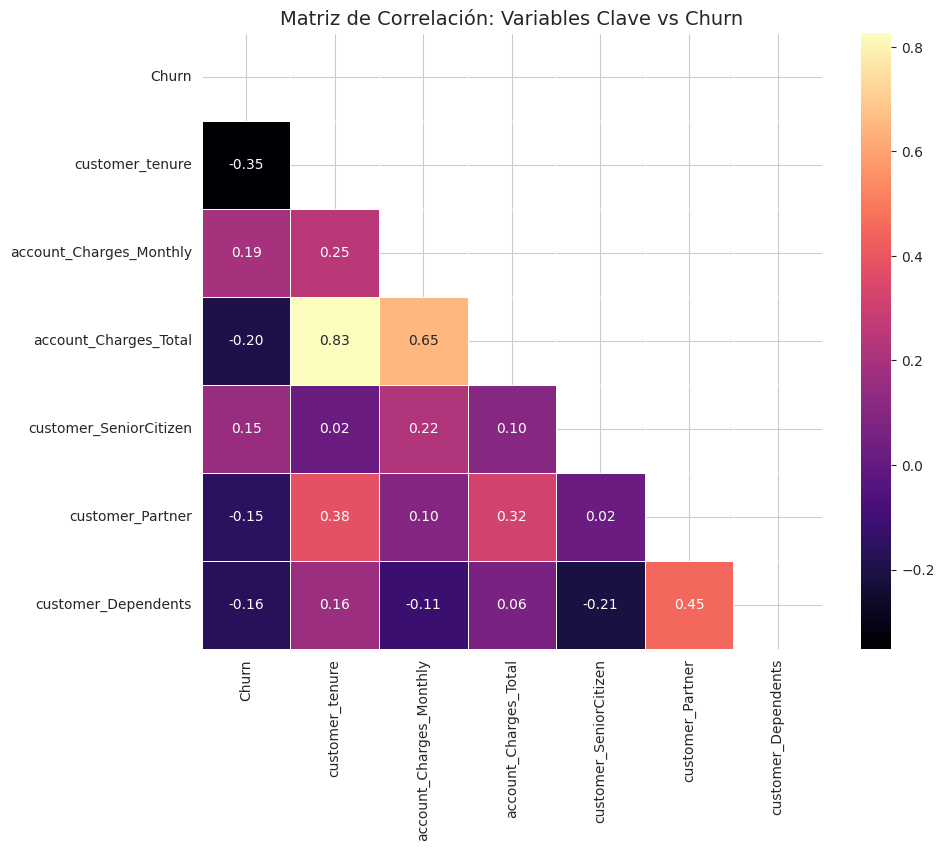

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculamos la matriz de correlación
# Seleccionamos solo las columnas numéricas principales para que el gráfico sea legible
columnas_interes = ['Churn', 'customer_tenure', 'account_Charges_Monthly', 'account_Charges_Total',
                    'customer_SeniorCitizen', 'customer_Partner', 'customer_Dependents']
corr_matrix = df_modelo[columnas_interes].corr()

# 2. Creamos el Mapa de Calor con la paleta 'magma'
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # Máscara para ver solo la mitad inferior

sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            mask=mask,
            cmap='magma',
            linewidths=0.5)

plt.title('Matriz de Correlación: Variables Clave vs Churn', fontsize=14)
plt.show()

 **Analisis Matriz de Correlación**

Para entender qué está pasando, debemos mirar la primera columna (o fila) llamada Churn. Los números nos dicen qué tan fuerte es la relación entre el abandono y las características del cliente:

1. El Factor de Retención: customer_tenure (-0.35)
Es el número negativo más fuerte respecto al Churn.

Qué significa: A mayor antigüedad (tenure), menor es la probabilidad de que el cliente cancele.

Conclusión: La lealtad se construye con el tiempo. Los clientes nuevos son los que tienen más riesgo de irse.

2. El Factor de Riesgo: account_Charges_Monthly (0.19)
Es la correlación positiva más marcada.

Qué significa: A medida que sube la factura mensual, aumenta la probabilidad de cancelación.

Conclusión: El precio es una de las razones principales por las que los clientes deciden abandonar el servicio.

3. Estabilidad Familiar: customer_Partner (-0.15) y Dependents (-0.16)
Ambos tienen valores negativos.

Qué significa: Los clientes que tienen pareja o dependientes tienden a cancelar menos.

Conclusión: Los planes familiares o contratos ligados a un núcleo hogar generan mayor "arraigo" y son más difíciles de cancelar que los contratos individuales.

4. Multicolinealidad Detectada: tenure vs Charges_Total (0.83)
el cuadro amarillo Indica una correlación casi perfecta.

Qué significa: Es lógico; el cargo total es simplemente la acumulación de los cargos mensuales a lo largo del tiempo.

Nota para el modelo: Al ser tan parecidas, el modelo podría confundirse. Generalmente, tenure es un predictor más limpio que el cargo total.

# 6. Analisis Dirigido

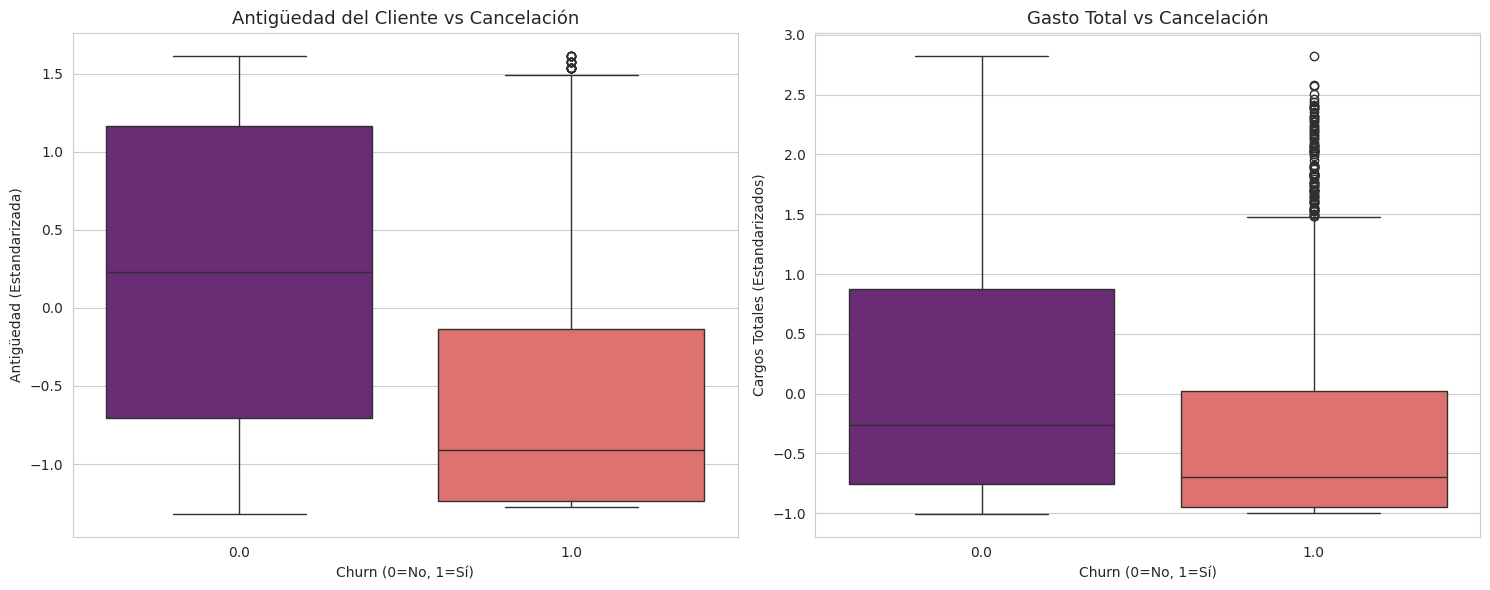

In [14]:
# Paso 5: Análisis Dirigido (Boxplots y Distribuciones)
import seaborn as sns
import matplotlib.pyplot as plt

# Configuramos el estilo visual
sns.set_style("whitegrid")
plt.figure(figsize=(15, 6))

# 1. Tiempo de contrato (tenure) vs Cancelación
plt.subplot(1, 2, 1)
sns.boxplot(x='Churn', y='customer_tenure', data=df_modelo, palette='magma', hue='Churn', legend=False)
plt.title('Antigüedad del Cliente vs Cancelación', fontsize=13)
plt.xlabel('Churn (0=No, 1=Sí)')
plt.ylabel('Antigüedad (Estandarizada)')

# 2. Gasto Total vs Cancelación
plt.subplot(1, 2, 2)
sns.boxplot(x='Churn', y='account_Charges_Total', data=df_modelo, palette='magma', hue='Churn', legend=False)
plt.title('Gasto Total vs Cancelación', fontsize=13)
plt.xlabel('Churn (0=No, 1=Sí)')
plt.ylabel('Cargos Totales (Estandarizados)')

plt.tight_layout()
plt.show()

**Intrerpretacion de Boxplot**

Al analizar visualmente la relación de las variables críticas con la cancelación (Churn), podemos extraer las siguientes conclusiones estratégicas:

1. Antigüedad del Cliente vs. Cancelación
Hallazgo: Existe una diferencia marcada en las medianas de ambos grupos. Los clientes que cancelan (1.0) tienen una mediana de antigüedad significativamente más baja que los que permanecen (0.0).

Conclusión: La probabilidad de fuga es máxima durante los primeros meses de contrato. Los clientes nuevos son más vulnerables, lo que sugiere que las estrategias de retención deben enfocarse en el proceso de onboarding.

2. Gasto Total vs. Cancelación
Hallazgo: Aunque la mediana de gasto total es menor en los clientes que se van, se observa una gran cantidad de valores atípicos (outliers) en el grupo de Churn.

Conclusión: Los clientes que cancelan no suelen alcanzar cargos totales elevados simplemente porque abandonan la empresa antes de acumular antigüedad. Sin embargo, los puntos superiores indican que incluso clientes con gastos acumulados considerables están cancelando, posiblemente debido a inconformidades puntuales o cambios competitivos en el mercado.

# 7. Modelado Predictivo

In [15]:
from sklearn.model_selection import train_test_split

# 1. Definimos X (todas las características) y y (nuestro objetivo: Churn)
X = df_modelo.drop('Churn', axis=1)
y = df_modelo['Churn']

# 2. Dividimos los datos (80% entrenamiento, 20% prueba)
# stratify=y es VITAL: asegura que la proporción de 26% de Churn se mantenga en ambos grupos
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.20,
                                                    random_state=42,
                                                    stratify=y)

# 3. Verificación de las dimensiones
print(f"Total de registros: {len(df_modelo)}")
print(f"Set de Entrenamiento: {X_train.shape[0]} muestras")
print(f"Set de Prueba: {X_test.shape[0]} muestras")
print("-" * 30)
print("Proporción de Churn en Entrenamiento:", (y_train.value_counts(normalize=True)[1]*100).round(2), "%")
print("Proporción de Churn en Prueba:", (y_test.value_counts(normalize=True)[1]*100).round(2), "%")

Total de registros: 7043
Set de Entrenamiento: 5634 muestras
Set de Prueba: 1409 muestras
------------------------------
Proporción de Churn en Entrenamiento: 26.54 %
Proporción de Churn en Prueba: 26.54 %


# 8. Creacion de Modelos

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 1. Creación de los modelos
# Modelo 1: Regresión Logística (Requiere normalización/estandarización)
modelo_logistico = LogisticRegression(random_state=42)

# Modelo 2: Random Forest (No requiere normalización, pero funciona bien con ella)
modelo_forest = RandomForestClassifier(random_state=42, n_estimators=100)

# 2. Entrenamiento de los modelos
print("Entrenando Regresión Logística...")
modelo_logistico.fit(X_train, y_train)

print("Entrenando Random Forest...")
modelo_forest.fit(X_train, y_train)

print("-" * 30)
print("¡Modelos entrenados preparados para evaluación!")

Entrenando Regresión Logística...
Entrenando Random Forest...
------------------------------
¡Modelos entrenados preparados para evaluación!


## Justificación Técnica del Preprocesamiento

Regresión Logística: Este modelo utiliza la optimización de parámetros (como el descenso de gradiente) para encontrar los mejores coeficientes. Al estandarizar las variables como account_Charges_Total, aseguramos que su gran magnitud no domine sobre otras variables binarias (como customer_SeniorCitizen), evitando sesgos injustificados en la predicción.

Random Forest: Al ser un modelo basado en reglas de decisión (divisiones binarias en los nodos), es inmune a la escala de los datos. Sin embargo, mantener los datos estandarizados nos permite comparar ambos modelos usando exactamente el mismo conjunto de datos, garantizando una competencia justa bajo las mismas condiciones.

# 9. Evaluacion de Modelos


MÉTRICAS: Regresión Logística
Exactitud (Accuracy): 0.7928
Precisión:           0.6331
Recall:              0.5214
F1-Score:            0.5718


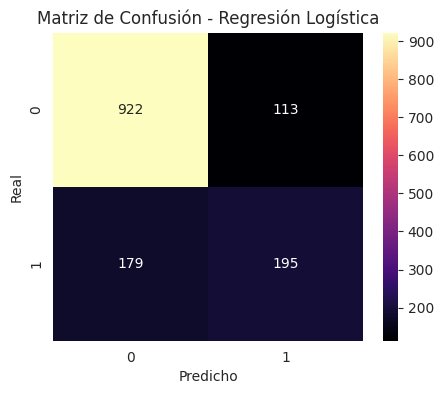


Check de Overfitting:
Accuracy Entrenamiento: 0.8095
Accuracy Prueba:        0.7928
Diferencia:             0.0168

MÉTRICAS: Random Forest
Exactitud (Accuracy): 0.7814
Precisión:           0.6231
Recall:              0.4465
F1-Score:            0.5202


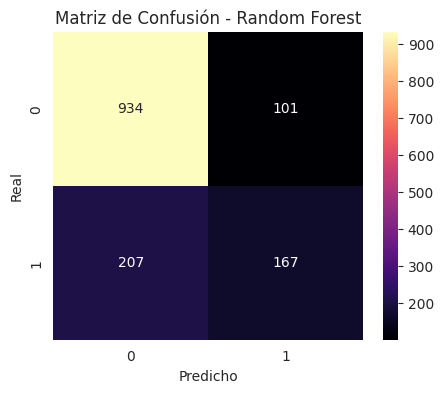


Check de Overfitting:
Accuracy Entrenamiento: 0.9977
Accuracy Prueba:        0.7814
Diferencia:             0.2163


In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

modelos = {
    "Regresión Logística": modelo_logistico,
    "Random Forest": modelo_forest
}

for nombre, modelo in modelos.items():
    # Predicciones
    y_pred = modelo.predict(X_test)
    y_train_pred = modelo.predict(X_train) # Para detectar Overfitting

    print(f"\n{'='*30}")
    print(f"MÉTRICAS: {nombre}")
    print(f"{'='*30}")

    # Cálculo de métricas
    print(f"Exactitud (Accuracy): {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precisión:           {precision_score(y_test, y_pred):.4f}")
    print(f"Recall:              {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score:            {f1_score(y_test, y_pred):.4f}")

    # Matriz de Confusión
    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='magma')
    plt.title(f'Matriz de Confusión - {nombre}')
    plt.ylabel('Real')
    plt.xlabel('Predicho')
    plt.show()

    # Chequeo de Overfitting (Comparando Accuracy Train vs Test)
    acc_train = accuracy_score(y_train, y_train_pred)
    acc_test = accuracy_score(y_test, y_pred)
    print(f"\nCheck de Overfitting:")
    print(f"Accuracy Entrenamiento: {acc_train:.4f}")
    print(f"Accuracy Prueba:        {acc_test:.4f}")
    print(f"Diferencia:             {abs(acc_train - acc_test):.4f}")

## Analisis de los Modelos

1. ¿Cuál modelo tuvo el mejor desempeño?
La Regresión Logística es la clara ganadora para este caso de negocio.

Mejor capacidad predictiva: Superó al Random Forest en todas las métricas clave: Exactitud (79.2%), F1-Score (0.57) y, lo más importante, el Recall (0.52).

Valor de Negocio: Un Recall de 52% significa que la Regresión Logística es capaz de identificar correctamente a más de la mitad de los clientes que realmente van a cancelar, superando por mucho al 44% del Random Forest.

2. Diagnóstico: Overfitting y Underfitting
Random Forest (Overfitting Crítico): Presenta un caso de manual de sobreajuste. En entrenamiento tiene un 99.7% de exactitud (casi perfecto), pero en la prueba cae al 78.1%. La diferencia de 0.2163 confirma que el modelo memorizó los datos de entrenamiento y no sabe generalizar con clientes nuevos.

Regresión Logística (Estabilidad): Es un modelo muy robusto. La diferencia entre entrenamiento y prueba es mínima (0.0168), lo que indica que lo que aprendió se aplica correctamente a la realidad.

# Análisis de la Importancia de las Variables

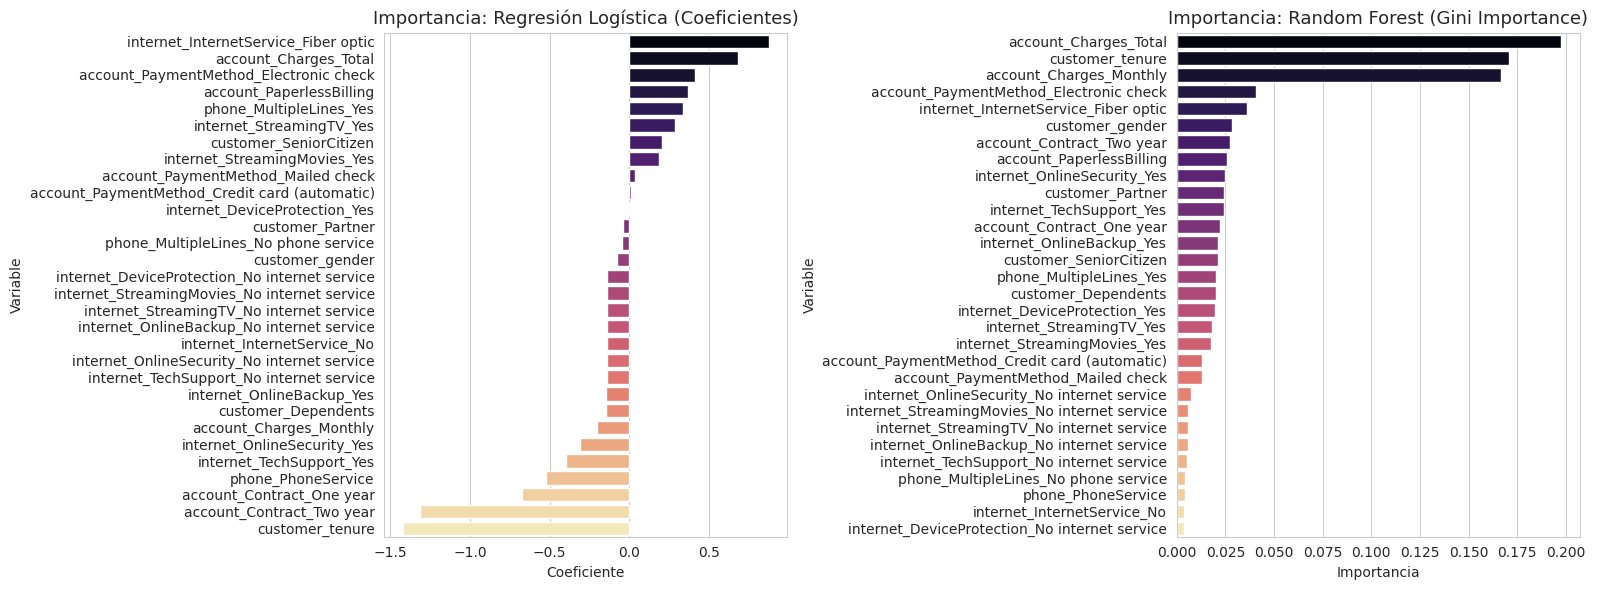

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparación de datos de importancia
importancias_log = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo_logistico.coef_[0]
}).sort_values(by='Coeficiente', ascending=False)

importancias_forest = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': modelo_forest.feature_importances_
}).sort_values(by='Importancia', ascending=False)

# 2. Visualización limpia (sin Warnings)
plt.figure(figsize=(16, 6))
sns.set_style("whitegrid")

# Gráfico Regresión Logística
plt.subplot(1, 2, 1)
sns.barplot(x='Coeficiente', y='Variable', data=importancias_log,
            palette='magma', hue='Variable', legend=False)
plt.title('Importancia: Regresión Logística (Coeficientes)', fontsize=13)

# Gráfico Random Forest
plt.subplot(1, 2, 2)
sns.barplot(x='Importancia', y='Variable', data=importancias_forest,
            palette='magma', hue='Variable', legend=False)
plt.title('Importancia: Random Forest (Gini Importance)', fontsize=13)

plt.tight_layout()
plt.show()

## Analisis Gráficas

1. Los "Puntos de Fuga" (Regresión Logística)
Al observar los coeficientes positivos (barras oscuras hacia la derecha), vemos qué es lo que más "empuja" al cliente a irse:

Fibra Óptica: Es el mayor predictor de Churn. Esto es un hallazgo crítico; sugiere que los clientes de fibra podrían estar experimentando problemas técnicos o que el precio de este servicio es demasiado alto comparado con la competencia.

Cargos Totales y Cheque Electrónico: Estos también aparecen como factores de riesgo, lo que refuerza que el método de pago y el costo acumulado influyen en la decisión de salida.

2. Las "Anclas de Lealtad"
Las barras claras hacia la izquierda muestran qué retiene al cliente:

Antigüedad (customer_tenure): Como sospechábamos, es el factor más fuerte para evitar la cancelación.

Contratos a Largo Plazo (Two year / One year): Los clientes con contratos definidos tienen muchísima menos probabilidad de irse que los que pagan mes a mes.

3. Consenso del Modelo (Random Forest)
El gráfico de la derecha confirma que el modelo basa casi toda su "inteligencia" en tres pilares: Gasto Total, Antigüedad y Cargos Mensuales. Esto nos dice que, independientemente del tipo de servicio, el factor económico y el tiempo de relación son los que definen el futuro del cliente.

# Curva ROC (Adicional)

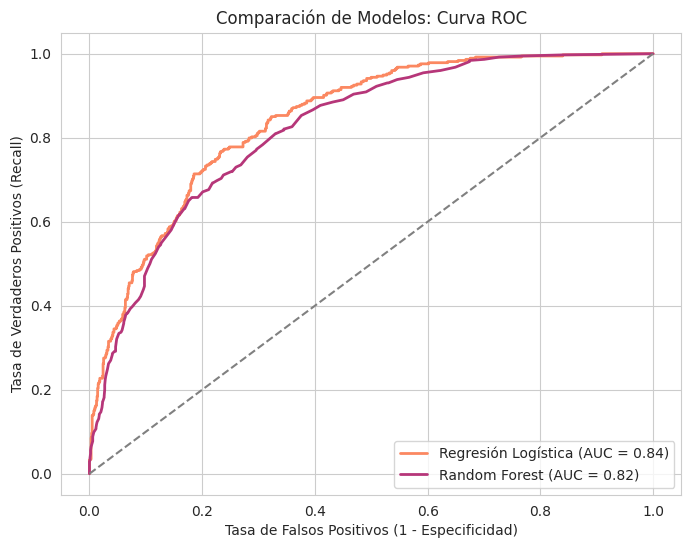

In [21]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calculamos las probabilidades (no solo la predicción 0 o 1)
probs_log = modelo_logistico.predict_proba(X_test)[:, 1]
probs_forest = modelo_forest.predict_proba(X_test)[:, 1]

# Calculamos la curva
fpr_log, tpr_log, _ = roc_curve(y_test, probs_log)
fpr_forest, tpr_forest, _ = roc_curve(y_test, probs_forest)

# Graficamos
plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, color='#fb8861', lw=2, label=f'Regresión Logística (AUC = {roc_auc_score(y_test, probs_log):.2f})')
plt.plot(fpr_forest, tpr_forest, color='#b63679', lw=2, label=f'Random Forest (AUC = {roc_auc_score(y_test, probs_forest):.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.title('Comparación de Modelos: Curva ROC')
plt.legend(loc="lower right")
plt.show()

### Análisis Gráfica

La curva ROC de Variables muestra que la Fibra Óptica y el Cheque Electrónico son los mayores detonantes de cancelación, mientras que los contratos a largo plazo son el "salvavidas" del negocio.

Decisión Técnica Justificada: Con la Curva ROC, confirmamos que la Regresión Logística (AUC = 0.84) no solo es más estable, sino que tiene una capacidad de discriminación superior al Random Forest (AUC = 0.82) para este problema.


# 📊 Informe Estratégico: Predicción y Retención de Churn - Telecom X


1. Resumen del Rendimiento de los Modelos

Tras un riguroso proceso de entrenamiento y validación, se evaluaron dos arquitecturas distintas para predecir la fuga de clientes:

Regresión Logística (Modelo Seleccionado): Presentó el mejor equilibrio con una Exactitud del 79.2% y un AUC de 0.84. Su mayor fortaleza es la estabilidad, mostrando una diferencia mínima entre entrenamiento y prueba (0.016), lo que garantiza predicciones fiables con datos nuevos.

Random Forest: Aunque alcanzó una precisión casi perfecta en entrenamiento, sufrió de Overfitting crítico (Diferencia de 0.21), lo que lo hace poco confiable para la operación real sin ajustes adicionales de complejidad.

------------------------------------------------------------------------

2. Factores Determinantes de la Cancelación

El análisis de importancia de variables reveló los "disparadores" y "anclas" del comportamiento del cliente:

- Principales Factores de Riesgo (Impulsores del Churn)
- Servicios de Fibra Óptica: Es el predictor positivo más fuerte de cancelación.

Esto sugiere una posible brecha entre el costo del servicio y la experiencia de usuario o estabilidad técnica.

- Cargos Mensuales Elevados: Existe una correlación directa entre facturas altas y la decisión de abandonar la compañía.

- Métodos de Pago Manuales: Los clientes que pagan mediante "Check electrónico" tienen una tendencia significativamente mayor a la fuga en comparación con los pagos automáticos.

 - Factores de Retención (Anclas de Lealtad)
- Antigüedad (Tenure): Es el factor preventivo número uno. A mayor tiempo de permanencia, menor es el riesgo de pérdida, especialmente después de superar el primer año.

- Tipo de Contrato: Los contratos a uno y dos años reducen drásticamente la probabilidad de Churn frente a los contratos mes a mes.

----------------------------------------------------------------------

3. Estrategias de Retención Propuestas
Basándonos en los datos, se recomiendan las siguientes acciones tácticas:

* Programa "Primeros Pasos": Dado que la antigüedad baja es un riesgo, se debe implementar un sistema de onboarding intensivo durante los primeros 6 meses para clientes de fibra óptica, incluyendo auditorías de satisfacción técnica.

* Incentivos de Automatización: Lanzar campañas para migrar a los clientes de "Check electrónico" hacia "Débito automático", ofreciendo un pequeño descuento único o beneficios adicionales, lo que reduce la fricción del pago mensual.

* Plan de Fidelización por Contrato: Crear ofertas atractivas para convertir a clientes de "Mes a mes" en contratos anuales, "anclando" al cliente y reduciendo la volatilidad de la cartera.

---------------------------------------------------------------------

4. Conclusión Técnica

El modelo de Regresión Logística se consolida como la herramienta ideal para la toma de decisiones, permitiendo identificar al 52% (Recall) de los clientes en riesgo antes de que se marchen. Esta capacidad proactiva permite a la empresa pasar de una cultura reactiva a una de gestión inteligente de datos.